### <h1 align="center" >Fig. 2d, 2e, 2h, 2i: Spindle and chromosome dynamics as function of cell size</h1>
This notebook is used to plot for the final spindle length and the final chromosome segregation distance as a function of cell size while fitting a linear regression function to the data. Three different embryonic conditions (Wild-type, Big: C27D9.1, Small: ani-2) were computed for in this notebook

The linear regression fit allows for the extraction of several parameters as follows:

   * Slope of the plot
   * Standard deviation of the slope
   * Standard error of the slope
   * Margin of error of the slope
   * t-statistic
   * *p-value* of the slope
   * $r^{2}$ of the fit

**`Input`:**

The input data comprise of different .CSV files containing datasets of various parameters for the three embryonic conditions. The dataset for each embryonic condition is contained in the following files which are loaded for computing various functions in this notebook:

* **Dynamics_analysis_summary ().csv**
* **Final pole_to_pole_length ().csv**
* **Final chromosome_to_chromosome_length ().csv**
* **Fit_Result_pole_pole_individual ().csv'**
* **Fit_Result_chromosome_chromosome_Individual ().csv**

**`Output`:**

The output files comprise of the following files:

* Plot for the final pole-to-pole elongation distance **(Final spindle length)** as a function cell length **(Estimated cell size)** for the wild-type embryo
* Plot for the final pole-to-pole elongation distance **(Final spindle length)** as a function cell length **(Estimated cell size)** for the Big embryo
* Plot for the final pole-to-pole elongation distance **(Final spindle length)** as a function cell length **(Estimated cell size)** for the Small embryo
* A combined plots of the final pole-to-pole elongation distance **(Final spindle length)** as a function cell length **(Estimated cell size)** for the three embryonic conditions.
* Plot for the final chromosome-to-chromosome segregation distance **Final length** as a function cell length **(Estimated cell size)** for the wild-type embryo
* Plot for the final chromosome-to-chromosome segregation distance **Final length** as a function cell length **(Estimated cell size)** for the Big embryo
* Plot for the final chromosome-to-chromosome segregation distance **Final length** as a function cell length **(Estimated cell size)** for the Small embryo
* A combined plots of the final chromosome-to-chromosome segregation distance **Final length** as a function cell length **(Estimated cell size)** for the three embryonic conditions.
* A .CSV file containing the values of the extracted parameters from the plots

#### !Note
The blocks of code to compute for the final pole-to-pole distance and the final chromosome-to-chromosome distance should be run alternatively for each quantitative analysis.

In [2]:
# library
import os
import numpy as np
import pandas as pd
import seaborn as sns
import itertools
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
# from sklearn.linear_model import LinearRegression
from scipy.stats import t
from sklearn.metrics import r2_score

In [3]:
# input folder
folder = r'E:\data\Analysis Data\01_python_analysis\input'
fileTable = os.listdir(folder)

# # output folder
save_files = r'E:\data\Analysis Data\01_python_analysis\output'

In [5]:
# define a class for the spindle analysis 
class SpindleAnalysis:

    def __init__(self, folder, fileTable):
        self.folder = folder
        self.fileTable = fileTable
        self.fileList = self._load_fileList_data()
        self._initialize_dataframe()
        self.wt_variable_columns()
        self.big_variable_columns()
        self.small_variable_columns()

    # create a list from the input files use for the analysis
    def _load_fileList_data(self):
        fileList = []
        filenames = [
            # Wild-type embryo
            '00_Dynamics_analysis_summary (WT).csv', 
            '02_Final pole_to_pole_length (WT).csv', 
            '01_Final chromosome_to_chromosome_length (WT).csv', 
            '00_Fit_Result_pole_pole_individual (wild-type).csv', 
            '00_Fit_Result_chromosome_chromosome_Individual (wild-type).csv', 
            
            # big embryo 
            '01_Dynamics_analysis_summary (big).csv', 
            '02_Final pole_to_pole_length (big).csv', 
            '01_Final chromosome_to_chromosome_length (big).csv', 
            '00_Fit_Result_pole_pole_individual (c27d9.1-RNAi).csv', 
            '00_Fit_Result_chromosome_chromosome_individual (c27d9.1-RNAi).csv', 
            
            # small embryo
            '01_Dynamics_analysis_summary (small).csv', 
            '02_Final pole_to_pole_length (small).csv', 
            '01_Final chromosome_to_chromosome_length (small).csv', 
            '00_Fit_Result_pole_pole_Individual (ani2-RNAi).csv', 
            '00_Fit_Result_chromosome_chromosome_Individual (ani2-RNAi).csv' 
        ]
        
        for file in self.fileTable:
            filepath = os.path.join(self.folder, file)
            filename = os.path.basename(filepath)
            
            if filename in filenames:
                try:
                    df = pd.read_csv(filepath, index_col=None, encoding='utf-8')
                except UnicodeDecodeError:
                    df = pd.read_csv(filepath, index_col=None, encoding='cp1252')
                except FileNotFoundError:
                    print(f"File not found: {filepath}")
                    continue
                fileList.append(df)
                
        return fileList

    # create new variables for different parameters to be used for further analysis 
    # this is done for all parameters from the 3 different data of the embryoes
    def _initialize_dataframe(self):
        
        '''WT embryo'''
        self.wt_table_summary = self.fileList[0]
        self.wt_final_pole_table = self.fileList[14]
        self.wt_final_chromosome_table = self.fileList[11]
        self.wt_fit_pole_table = self.fileList[6]
        self.wt_fit_chromosome_table = self.fileList[3]
        self.wt_IL_raw = self.wt_fit_pole_table['Initial pole_pole length (µm)'].values # initial length
        self.wt_FL_raw = self.wt_fit_pole_table['Final pole_pole length (µm)'].values # final length
        self.wt_cell_length_error = self.wt_table_summary['Error propagation'].values 
        self.wt_final_poles = self.wt_table_summary['Final pole-to-pole (µm)']
        self.wt_std_final_poles = self.wt_table_summary['Final pole-to-pole std'].values 
        self.wt_initial_poles = self.wt_table_summary['Initial pole-to-pole (µm)'].values 
        self.wt_std_initial_poles = self.wt_table_summary['Initial pole-to-pole std'].values 
        self.wt_final_chromosome = self.wt_table_summary['Final chromosome-to-chromosome (µm)'].values 
        self.wt_std_final_chromosome = self.wt_table_summary['Final chromosome-to-chromosome std'].values 
        self.wt_elongation = self.wt_table_summary['Elongation rate pole-to-pole (µm/min)'].values 
        self.wt_std_elongation = self.wt_table_summary['Elongation rate pole-to-pole std'].values 
        self.wt_segregation = self.wt_table_summary['segregation speed chromosome-to-chromosome (µm/min)'].values 
        self.wt_std_segregation = self.wt_table_summary['segregation speed chromosome-to-chromosome std'].values 
        
        
        '''big embryo'''
        self.big_table_summary = self.fileList[7]
        self.big_final_pole_table = self.fileList[12]
        self.big_final_chromosome_table = self.fileList[9]
        self.big_fit_pole_table = self.fileList[5]
        self.big_fit_chromosome_table = self.fileList[2]
        self.big_IL_raw = self.big_fit_pole_table['Initial pole_pole length (µm)'].values # initial length
        self.big_FL_raw = self.big_fit_pole_table['Final pole_pole length (µm)'].values # final length
        self.big_cell_length_error = self.big_table_summary['Error propagation'].values 
        self.big_final_poles = self.big_table_summary['Final pole-to-pole (µm)'].values 
        self.big_std_final_poles = self.big_table_summary['Final pole-to-pole std'].values 
        self.big_initial_poles = self.big_table_summary['Initial pole-to-pole (µm)'].values 
        self.big_std_initial_poles = self.big_table_summary['Initial pole-to-pole std'].values 
        self.big_final_chromosome = self.big_table_summary['Final chromosome-to-chromosome (µm)'].values 
        self.big_std_final_chromosome = self.big_table_summary['Final chromosome-to-chromosome std'].values 
        self.big_elongation = self.big_table_summary['Elongation rate pole-to-pole (µm/min)'].values 
        self.big_std_elongation = self.big_table_summary['Elongation rate pole-to-pole std'].values 
        self.big_segregation = self.big_table_summary['segregation speed chromosome-to-chromosome (µm/min)'].values 
        self.big_std_segregation = self.big_table_summary['segregation speed chromosome-to-chromosome std'].values 
        
        
        '''small embryo'''
        self.small_table_summary = self.fileList[8]
        self.small_final_pole_table = self.fileList[13]
        self.small_final_chromosome_table = self.fileList[10]
        self.small_fit_pole_table = self.fileList[4]
        self.small_fit_chromosome_table = self.fileList[1]
        self.small_IL_raw = self.small_fit_pole_table['Initial pole_pole length (µm)'].values # initial length
        self.small_FL_raw = self.small_fit_pole_table['Final pole_pole length (µm)'].values # final length
        self.small_cell_length_error = self.small_table_summary['Error propagation'].values 
        self.small_final_poles = self.small_table_summary['Final pole-to-pole (µm)'].values 
        self.small_std_final_poles = self.small_table_summary['Final pole-to-pole std'].values 
        self.small_initial_poles = self.small_table_summary['Initial pole-to-pole (µm)'].values 
        self.small_std_initial_poles = self.small_table_summary['Initial pole-to-pole std'].values 
        self.small_final_chromosome = self.small_table_summary['Final chromosome-to-chromosome (µm)'].values 
        self.small_std_final_chromosome = self.small_table_summary['Final chromosome-to-chromosome std'].values 
        self.small_elongation = self.small_table_summary['Elongation rate pole-to-pole (µm/min)'].values 
        self.small_std_elongation = self.small_table_summary['Elongation rate pole-to-pole std'].values 
        self.small_segregation = self.small_table_summary['segregation speed chromosome-to-chromosome (µm/min)'].values 
        self.small_std_segregation = self.small_table_summary['segregation speed chromosome-to-chromosome std'].values 
        
    '''Get the cell length values for the 3 embryonic conditions'''
    # Wild-type
    def get_wt_cell_length(self):
        cell_column = self.wt_table_summary.loc[:, 'Cell']
        wt_cell_length_column = self.wt_table_summary.loc[:, 'Cell length (µm)']
        wt_cell_length = pd.concat([cell_column, wt_cell_length_column], axis=1, sort=False)
        return wt_cell_length
    # Big embryo
    def get_big_cell_length(self):
        cell_column = self.big_table_summary.loc[:, 'Cell']
        big_cell_length_column = self.big_table_summary.loc[:, 'Cell length (µm)']
        big_cell_length = pd.concat([cell_column, big_cell_length_column], axis=1, sort=False)
        return big_cell_length

    # Small embryo 
    def get_small_cell_length(self):
        cell_column = self.small_table_summary.loc[:, 'Cell']
        small_cell_length_column = self.small_table_summary.loc[:, 'Cell length (µm)']
        small_cell_length = pd.concat([cell_column, small_cell_length_column], axis=1, sort=False)
        return small_cell_length

    '''Create a long-form table to merge the data of the parameter of interest with the cell length values'''
    # pole-to-pole distance values
    def mergePoleTable(self, condition_cell_length, condition_final_pole_table):                        ############ reminder: insert the right parameter
        cell_length = condition_cell_length
        newTable = pd.merge(condition_final_pole_table.melt(), cell_length, left_on='variable', right_on='Cell').dropna()
        return newTable

    # chromosome-to-chromosome distance values
    def mergeChromosomeTable(self, condition_cell_length, condition_final_chromosome_table):           ############ reminder: insert the right parameter
        cell_length = condition_cell_length
        newTable = pd.merge(condition_final_chromosome_table.melt(), cell_length, left_on='variable', right_on='Cell').dropna()
        return newTable

    # linear regression function of 1D polynomial
    def linear_fit(self, cell_length_fit, final_length_fit):
        x_data = cell_length_fit
        y_data = final_length_fit

        fitresult, cov = np.polyfit(x_data, y_data, 1, cov=True)                                          # fit a polynomial function of 1 degree to the x- and y-values data with covariance matrix
        slope = fitresult[0]
        intercept = fitresult[1]
        slope_std_dev = np.sqrt(cov[0, 0])                                                                # extract the standard deviation of the slope from the covariance matrix
        t_stat = slope / slope_std_dev                                                                    # calculate the t-statistic for the slope
        df = len(x_data) - 2                                                                              # degrees of freedom: number of data points minus number of parameters
        p_value = 2 * (1 - t.cdf(np.abs(t_stat), df))                                                     # calculate the p-value from the t-distribution
        x_fit = np.linspace(np.min(x_data) - 10, np.max(x_data) + 10, 500)                                # create x-values from the x-input data
        y_fit = np.polyval(fitresult, x_fit)                                                              # calculate y-fit values
        SE_y = np.sqrt(np.sum((y_data - np.polyval(fitresult, x_data))**2) / (len(y_data) - 2))           # standard error of the regression estimate
        SSD = np.sum((x_data - np.mean(x_data))**2)                                                       # sum of squared deviations of x_data from its mean
        SE_x = SE_y * np.sqrt(1/len(x_data) + (x_fit - np.mean(x_data))**2 / SSD)                         # standard errors of each predicted value
        ci = t.ppf(0.975, len(x_data) - 2) * SE_x                                                         # confidence interval
        upper_ci = y_fit + ci
        lower_ci = y_fit - ci
        SE_slope = SE_y / np.sqrt(SSD)                                                                    # calculate SE for the slope
        t_critical = t.ppf(0.975, len(x_data) - 2)                                                        # get the critical t value
        margin_of_error_slope = t_critical * SE_slope                                                     # calculate the margin of error for the slope
        r_squared = r2_score(y_data, np.polyval(fitresult, x_data))                                       # calculate R-squared
        
        return x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared
    
    def plot_WildType_final_distances(self):
        markers = ['s', 'D', '^', 'o', 'H', 'p']
        marker_cycle = itertools.cycle(markers)
        wt_poles_data = self.mergePoleTable(self.get_wt_cell_length(), self.wt_final_pole_table)
        wt_chromosomes_data = self.mergeChromosomeTable(self.get_wt_cell_length(), self.wt_final_chromosome_table)
        variable_column_poles = wt_poles_data['variable']
        variable_column_chromosomes = wt_chromosomes_data['variable']
        plt.figure(figsize=(8, 8))
    
        # ############################################ POLES FINAL DISTANCE PLOT #################################################
        # '''individual data plot'''
        # for i, col in enumerate(variable_column_poles.unique()):
        #     ax = sns.scatterplot(data=wt_poles_data[wt_poles_data['variable'] == col], 
        #                          x='Cell length (µm)', y='value',
        #                          marker=markers[i], s=100, color='gray', alpha=0.5, legend=None)
        # ax.errorbar(x=self.get_wt_cell_length()['Cell length (µm)'], y=self.wt_final_poles, 
        #             xerr=self.wt_cell_length_error, yerr=self.wt_std_final_poles, 
        #             capsize=2, elinewidth=1.5, fmt='none', color='#004C99')
        
        # '''mean data plot'''
        # for i_wt_mean in range(len(self.get_wt_cell_length()['Cell length (µm)'])):
        #     marker = next(marker_cycle)
        #     plt.plot(self.get_wt_cell_length()['Cell length (µm)'][i_wt_mean], self.wt_final_poles[i_wt_mean], marker=marker, markersize=15, color='#004C99')

        # '''fit data plot'''
        # x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_wt_cell_length()['Cell length (µm)'], self.wt_final_poles)
        # plt.plot(x_fit, y_fit, '-', linewidth=4, color='#004C99')
        # plt.fill_between(x_fit, lower_ci, upper_ci, color='#004C99', alpha=0.2, edgecolor=None)
        
        ########################################### CHROMOSOMES FINAL DISTANCE PLOT #################################################
        
        '''individual data plot'''
        for i, col in enumerate(variable_column_chromosomes.unique()):
            ax = sns.scatterplot(data=wt_chromosomes_data[wt_chromosomes_data['variable'] == col], 
                                 x='Cell length (µm)', y='value',
                                 marker=markers[i], s=100, color='gray', alpha=0.5, legend=None, edgecolor='black')
        ax.errorbar(x=self.get_wt_cell_length()['Cell length (µm)'], y=self.wt_final_chromosome, 
                    xerr=self.wt_cell_length_error, yerr=self.wt_std_final_chromosome, 
                    capsize=2, elinewidth=1.5, fmt='none', color='#004C99')

        '''mean data plot'''
        for i_wt_mean in range(len(self.get_wt_cell_length()['Cell length (µm)'])):
            marker = next(marker_cycle)
            plt.plot(self.get_wt_cell_length()['Cell length (µm)'][i_wt_mean], self.wt_final_chromosome[i_wt_mean], 
                     marker=marker, markersize=15, color='#004C99', markeredgecolor='black')
        
        '''fit data plot'''
        x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_wt_cell_length()['Cell length (µm)'], self.wt_final_chromosome)
        plt.plot(x_fit, y_fit, '--', label='Fit', linewidth=4, color='#004C99')
        plt.fill_between(x_fit, lower_ci, upper_ci, color='#004C99', alpha=0.2, edgecolor=None)
        
        # Set major locator for x-axis and y-axis to only use integer values
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        # ax.set(ylim=(6, 25.5+.5), xlim=(6, 27))
        ax.set(ylim=(3, 26.5+0.5), xlim=(3, 26.5+0.5))

        ax.tick_params(axis='x', labelsize=15)
        ax.tick_params(axis='y', labelsize=15)
        ax.tick_params(axis='both', which='major', labelsize=15)
        ax.tick_params(axis='x', direction='in', size=12)
        ax.tick_params(axis='y', direction='in', size=12)
        ax.set_xlabel('Cell length [µm]', fontsize=25)
        ax.set_ylabel('Distance [µm]', fontsize=25)
        ax.figure.savefig(os.path.join(save_files, 'Final_distance_Chromosome-to-chromosome (WT).png'), dpi=600, bbox_inches='tight')
        ax.figure.savefig(os.path.join(save_files, 'Final_distance_Chromosome-to-chromosome (WT).tiff'), dpi=600, bbox_inches='tight')
        
        # ax.figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-pole (WT).png'), dpi=600, bbox_inches='tight')
        # ax.figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-pole (WT).tiff'), dpi=600, bbox_inches='tight')
        
        return None
    
    def plot_Big_final_distances(self):
        markers = ['s', 'D', '^', 'o', 'H', 'p']
        marker_cycle = itertools.cycle(markers)
        big_poles_data = self.mergePoleTable(self.get_big_cell_length(), self.big_final_pole_table)
        big_chromosomes_data = self.mergeChromosomeTable(self.get_big_cell_length(), self.big_final_chromosome_table)
        variable_column_poles = big_poles_data['variable']
        variable_column_chromosomes = big_chromosomes_data['variable']
        plt.figure(figsize=(6, 6))

        ############################################ POLES FINAL DISTANCE PLOT #################################################
        '''individual data plot'''
        for i, col in enumerate(variable_column_poles.unique()):
            ax = sns.scatterplot(data=big_poles_data[big_poles_data['variable'] == col], 
                                 x='Cell length (µm)', y='value',
                                 marker=markers[i], s=100, color='gray', alpha=0.5, legend=None)
        ax.errorbar(x=self.get_big_cell_length()['Cell length (µm)'], y=self.big_final_poles, 
                    xerr=self.big_cell_length_error, yerr=self.big_std_final_poles, 
                    capsize=2, elinewidth=1.5, fmt='none', color='#CC6600')

        '''mean data plot'''
        for i_big_mean in range(len(self.get_big_cell_length()['Cell length (µm)'])):
            marker = next(marker_cycle)
            plt.plot(self.get_big_cell_length()['Cell length (µm)'][i_big_mean], self.big_final_poles[i_big_mean], 
                     marker=marker, markersize=15, color='#CC6600')
        
        '''fit data plot'''
        x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_big_cell_length()['Cell length (µm)'], self.big_final_poles)
        plt.plot(x_fit, y_fit, '-', linewidth=4, color='#CC6600')
        plt.fill_between(x_fit, lower_ci, upper_ci, color='#CC6600', alpha=0.2, edgecolor=None)

        ############################################ CHROMOSOMES FINAL DISTANCE PLOT #################################################

        # '''individual data plot'''
        # for i, col in enumerate(variable_column_chromosomes.unique()):
        #     ax = sns.scatterplot(data=big_chromosomes_data[big_chromosomes_data['variable'] == col], 
        #                          x='Cell length (µm)', y='value',
        #                          marker=markers[i], s=100, color='gray', alpha=0.5, legend=None, edgecolor='black')
        # ax.errorbar(x=self.get_big_cell_length()['Cell length (µm)'], y=self.big_final_chromosome, 
        #             xerr=self.big_cell_length_error, yerr=self.big_std_final_chromosome, 
        #             capsize=2, elinewidth=1.5, fmt='none', color='#CC6600')

        # '''mean data plot'''
        # for i_big_mean in range(len(self.get_big_cell_length()['Cell length (µm)'])):
        #     marker = next(marker_cycle)
        #     plt.plot(self.get_big_cell_length()['Cell length (µm)'][i_big_mean], self.big_final_chromosome[i_big_mean], 
        #              marker=marker, markersize=15, color='#CC6600', markeredgecolor='black')
        
        # '''fit data plot'''
        # x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_big_cell_length()['Cell length (µm)'], self.big_final_chromosome)
        # plt.plot(x_fit, y_fit, '--', label='Fit', linewidth=4, color='#CC6600')
        # plt.fill_between(x_fit, lower_ci, upper_ci, color='#CC6600', alpha=0.2, edgecolor=None)

        # Set major locator for x-axis and y-axis to only use integer values
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        # ax.set(ylim=(6, 25.5+.5), xlim=(6, 27))
        ax.set(ylim=(3, 26.5+0.5), xlim=(3, 26.5+0.5))

        ax.tick_params(axis='x', labelsize=15)
        ax.tick_params(axis='y', labelsize=15)
        ax.tick_params(axis='both', which='major', labelsize=15)
        ax.tick_params(axis='x', direction='in', size=12)
        ax.tick_params(axis='y', direction='in', size=12)
        ax.set_xlabel('Cell length [µm]', fontsize=25)
        ax.set_ylabel('Distance [µm]', fontsize=25)
        # ax.figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-pole_and_Chromosome-to-chromosome (BIG).png'), dpi=400, bbox_inches='tight')
        # ax.figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-pole_and_Chromosome-to-chromosome (BIG).tiff'), dpi=400, bbox_inches='tight')
        
        ax.figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-pole (BIG).png'), dpi=600, bbox_inches='tight')
        ax.figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-pole (BIG).tiff'), dpi=600, bbox_inches='tight')

        return None
    
    def plot_Small_final_distances(self):
        markers = ['s', 'D', '^', 'o', 'H', 'p']
        marker_cycle = itertools.cycle(markers)
        small_poles_data = self.mergePoleTable(self.get_small_cell_length(), self.small_final_pole_table)
        small_chromosomes_data = self.mergeChromosomeTable(self.get_small_cell_length(), self.small_final_chromosome_table)
        variable_column_poles = small_poles_data['variable']
        variable_column_chromosomes = small_chromosomes_data['variable']
        plt.figure(figsize=(6, 6))

        ############################################ POLES FINAL DISTANCE PLOT #################################################
        '''individual data plot'''
        for i, col in enumerate(variable_column_poles.unique()):
            ax = sns.scatterplot(data=small_poles_data[small_poles_data['variable'] == col], 
                                 x='Cell length (µm)', y='value',
                                 marker=markers[i], s=100, color='gray', alpha=0.5, legend=None)
        ax.errorbar(x=self.get_small_cell_length()['Cell length (µm)'], y=self.small_final_poles, 
                    xerr=self.small_cell_length_error, yerr=self.small_std_final_poles, 
                    capsize=2, elinewidth=1.5, fmt='none', color='#009999')

        '''mean data plot'''
        for i_small_mean in range(len(self.get_small_cell_length()['Cell length (µm)'])):
            marker = next(marker_cycle)
            plt.plot(self.get_small_cell_length()['Cell length (µm)'][i_small_mean], self.small_final_poles[i_small_mean], 
                     marker=marker, markersize=15, color='#009999')

        '''fit data plot'''
        x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_small_cell_length()['Cell length (µm)'], self.small_final_poles)
        plt.plot(x_fit, y_fit, '-', linewidth=4, color='#009999')
        plt.fill_between(x_fit, lower_ci, upper_ci, color='#009999', alpha=0.2, edgecolor=None)

        ############################################ CHROMOSOMES FINAL DISTANCE PLOT #################################################

        # '''individual data plot'''
        # for i, col in enumerate(variable_column_chromosomes.unique()):
        #     ax = sns.scatterplot(data=small_chromosomes_data[small_chromosomes_data['variable'] == col], 
        #                          x='Cell length (µm)', y='value',
        #                          marker=markers[i], s=100, color='gray', alpha=0.5, legend=None, edgecolor='black')
        # ax.errorbar(x=self.get_small_cell_length()['Cell length (µm)'], y=self.small_final_chromosome, 
        #             xerr=self.small_cell_length_error, yerr=self.small_std_final_chromosome, 
        #             capsize=2, elinewidth=1.5, fmt='none', color='#009999')

        # '''mean data plot'''
        # for i_small_mean in range(len(self.get_small_cell_length()['Cell length (µm)'])):
        #     marker = next(marker_cycle)
        #     plt.plot(self.get_small_cell_length()['Cell length (µm)'][i_small_mean], self.small_final_chromosome[i_small_mean], 
        #              marker=marker, markersize=15, color='#009999', markeredgecolor='black')        

        # '''fit data plot'''
        # x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_small_cell_length()['Cell length (µm)'], self.small_final_chromosome)
        # plt.plot(x_fit, y_fit, '--', label='Fit', linewidth=4, color='#009999')
        # plt.fill_between(x_fit, lower_ci, upper_ci, color='#009999', alpha=0.2, edgecolor=None)

        # Set major locator for x-axis and y-axis to only use integer values
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        # ax.set(ylim=(6, 25.5+.5), xlim=(6, 27))
        ax.set(ylim=(3, 26.5+0.5), xlim=(3, 26.5+0.5))

        ax.tick_params(axis='x', labelsize=15)
        ax.tick_params(axis='y', labelsize=15)
        ax.tick_params(axis='both', which='major', labelsize=15)
        ax.tick_params(axis='x', direction='in', size=12)
        ax.tick_params(axis='y', direction='in', size=12)
        ax.set_xlabel('Cell length [µm]', fontsize=25)
        ax.set_ylabel('Distance [µm]', fontsize=25)
        ax.figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-pole_and_Chromosome-to-chromosome (SMALL).png'), dpi=400, bbox_inches='tight')
        ax.figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-pole_and_Chromosome-to-chromosome (SMALL).tiff'), dpi=400, bbox_inches='tight')
        
        return None

    def wt_variable_columns(self):
        self.wt_poles_data = self.mergePoleTable(self.get_wt_cell_length(), self.wt_final_pole_table)
        self.wt_chromosomes_data = self.mergeChromosomeTable(self.get_wt_cell_length(), self.wt_final_chromosome_table)
        self.wt_variable_column_poles = self.wt_poles_data['variable']
        self.wt_variable_column_chromosomes = self.wt_chromosomes_data['variable']

    def big_variable_columns(self):    
        self.big_poles_data = self.mergePoleTable(self.get_big_cell_length(), self.big_final_pole_table)
        self.big_chromosomes_data = self.mergeChromosomeTable(self.get_big_cell_length(), self.big_final_chromosome_table)
        self.big_variable_column_poles = self.big_poles_data['variable']
        self.big_variable_column_chromosomes = self.big_chromosomes_data['variable']

    def small_variable_columns(self):
        self.small_poles_data = self.mergePoleTable(self.get_small_cell_length(), self.small_final_pole_table)
        self.small_chromosomes_data = self.mergeChromosomeTable(self.get_small_cell_length(), self.small_final_chromosome_table)
        self.small_variable_column_poles = self.small_poles_data['variable']
        self.small_variable_column_chromosomes = self.small_chromosomes_data['variable']

    def plot_combined_summary(self):
        markers = ['s', 'D', '^', 'o', 'H', 'p']
        marker_cycle = itertools.cycle(markers)
        plt.figure(figsize=(8, 8))
        
        # #################################################################### Pole-to-pole final distance ##########################################################################
        # '''WILD-TYPE'''
        # # for i, col in enumerate(self.wt_variable_column_poles.unique()):
        # #     ax = sns.scatterplot(data=self.wt_poles_data[self.wt_poles_data['variable'] == col], 
        # #                          x='Cell length (µm)', y='value', 
        # #                          marker=markers[i], s=50, color='#004C99', alpha=0.2, legend=None)
        
        # plt.errorbar(x=self.get_wt_cell_length()['Cell length (µm)'], y=self.wt_final_poles, 
        #             xerr=self.wt_cell_length_error, yerr=self.wt_std_final_poles, 
        #             capsize=2, elinewidth=1.5, fmt='none', color='#004C99')
        
        # '''mean data plot'''
        # for i_wt in range(len(self.get_wt_cell_length()['Cell length (µm)'])):
        #     marker = next(marker_cycle)
        #     plt.plot(self.get_wt_cell_length()['Cell length (µm)'][i_wt], self.wt_final_poles[i_wt], 
        #             marker=marker, markersize=15, color='#004C99')
        
        # '''fit data plot'''
        # x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_wt_cell_length()['Cell length (µm)'], self.wt_final_poles)
        # plt.plot(x_fit, y_fit, '-', linewidth=4, color='#004C99')
        # plt.fill_between(x_fit, lower_ci, upper_ci, color='#004C99', alpha=0.1, edgecolor=None)
        
        # #################################################################### Pole-to-pole final distance ##########################################################################
        # '''BIG EMBRYO DATA'''
        # # for j, col_big in enumerate(self.big_variable_column_poles.unique()):
        # #     ax1 = sns.scatterplot(data=self.big_poles_data[self.big_poles_data['variable'] == col_big], 
        # #                           x='Cell length (µm)', y='value', 
        # #                           marker=markers[j], s=50, color='#CC6600', alpha=0.2, legend=None, ax=ax)
            
        # plt.errorbar(x=self.get_big_cell_length()['Cell length (µm)'], y=self.big_final_poles, 
        #              xerr=self.big_cell_length_error, yerr=self.big_std_final_poles, 
        #              capsize=2, elinewidth=1.5, fmt='none', color='#CC6600')
        
        # '''mean data plot'''
        # for i_big in range(len(self.get_big_cell_length()['Cell length (µm)'])):
        #     marker = next(marker_cycle)
        #     plt.plot(self.get_big_cell_length()['Cell length (µm)'][i_big], self.big_final_poles[i_big], 
        #             marker=marker, markersize=15, color='#CC6600')
            
        # '''fit data plot'''
        # x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_big_cell_length()['Cell length (µm)'], self.big_final_poles)
        # plt.plot(x_fit, y_fit, '-', linewidth=4, color='#CC6600')
        # plt.fill_between(x_fit, lower_ci, upper_ci, color='#CC6600', alpha=0.1, edgecolor=None)
        
        # #################################################################### Pole-to-pole final distance ##########################################################################
        # '''SMALL EMBRYO DATA'''
        # # for k, col_small in enumerate(self.small_variable_column_poles.unique()):
        # #     ax2 = sns.scatterplot(data=self.small_poles_data[self.small_poles_data['variable'] == col_small], 
        # #                           x='Cell length (µm)', y='value', 
        # #                           marker=markers[k], s=50, color='#009999', alpha=0.2, legend=None, ax=ax) 
        
        # plt.errorbar(x=self.get_small_cell_length()['Cell length (µm)'], y=self.small_final_poles, 
        #             xerr=self.small_cell_length_error, yerr=self.small_std_final_poles, 
        #             capsize=2, elinewidth=1.5, fmt='none', color='#009999')

        # '''mean data plot'''
        # for i_small in range(len(self.get_small_cell_length()['Cell length (µm)'])):
        #     marker = next(marker_cycle)
        #     plt.plot(self.get_small_cell_length()['Cell length (µm)'][i_small], self.small_final_poles[i_small], 
        #             marker=marker, markersize=15, color='#009999')
    
        # '''fit data plot'''
        # x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_small_cell_length()['Cell length (µm)'], self.small_final_poles)
        # plt.plot(x_fit, y_fit, '-', linewidth=4, color='#009999')
        # plt.fill_between(x_fit, lower_ci, upper_ci, color='#009999', alpha=0.1, edgecolor=None)
        
        ################################################################### Chromosome-to-chromosome final distance ##########################################################################
        '''WILD-TYPE'''
        # for m, col in enumerate(self.wt_variable_column_chromosomes.unique()):
        #     sns.scatterplot(data=self.wt_chromosomes_data[self.wt_chromosomes_data['variable'] == col], 
        #                          x='Cell length (µm)', y='value', 
        #                          marker=markers[m], s=50, color='#004C99', alpha=0.2, legend=None, edgecolor='black', ax=ax)

        plt.errorbar(x=self.get_wt_cell_length()['Cell length (µm)'], y=self.wt_final_chromosome, 
                    xerr=self.wt_cell_length_error, yerr=self.wt_std_final_chromosome, 
                    capsize=2, elinewidth=1.5, fmt='none', color='#004C99')

        '''mean data plot'''
        for i_wt in range(len(self.get_wt_cell_length()['Cell length (µm)'])):
            marker = next(marker_cycle)
            plt.plot(self.get_wt_cell_length()['Cell length (µm)'][i_wt], self.wt_final_chromosome[i_wt], 
                    marker=marker, markersize=15, color='#004C99', markeredgecolor='black')

        '''fit data plot'''
        x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_wt_cell_length()['Cell length (µm)'], self.wt_final_chromosome)
        plt.plot(x_fit, y_fit, '--', linewidth=4, color='#004C99')
        plt.fill_between(x_fit, lower_ci, upper_ci, color='#004C99', alpha=0.1, edgecolor=None)

        #################################################################### Chromosome-to-chromosome final distance ##########################################################################
        '''BIG EMBRYO DATA'''
        # for n, col_big in enumerate(self.big_variable_column_chromosomes.unique()):
        #     sns.scatterplot(data=self.big_chromosomes_data[self.big_chromosomes_data['variable'] == col_big], 
        #                           x='Cell length (µm)', y='value', 
        #                           marker=markers[n], s=50, color='#CC6600', alpha=0.2, legend=None, edgecolor='black', ax=ax)

        plt.errorbar(x=self.get_big_cell_length()['Cell length (µm)'], y=self.big_final_chromosome, 
                     xerr=self.big_cell_length_error, yerr=self.big_std_final_chromosome, 
                     capsize=2, elinewidth=1.5, fmt='none', color='#CC6600')

        '''mean data plot'''
        for i_big in range(len(self.get_big_cell_length()['Cell length (µm)'])):
            marker = next(marker_cycle)
            plt.plot(self.get_big_cell_length()['Cell length (µm)'][i_big], self.big_final_chromosome[i_big], 
                    marker=marker, markersize=15, color='#CC6600', markeredgecolor='black')
        
        '''fit data plot'''
        x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_big_cell_length()['Cell length (µm)'], self.big_final_chromosome)
        plt.plot(x_fit, y_fit, '--', linewidth=4, color='#CC6600')
        plt.fill_between(x_fit, lower_ci, upper_ci, color='#CC6600', alpha=0.1, edgecolor=None)

        #################################################################### Chromosome-to-chromosome final distance ##########################################################################
        '''SMALL EMBRYO DATA'''
        # for k, col_small in enumerate(self.small_variable_column_chromosomes.unique()):
        #     sns.scatterplot(data=self.small_chromosomes_data[self.small_chromosomes_data['variable'] == col_small], 
        #                           x='Cell length (µm)', y='value', 
        #                           marker=markers[k], s=50, color='#009999', alpha=0.2, legend=None, edgecolor='black', ax=ax) 

        plt.errorbar(x=self.get_small_cell_length()['Cell length (µm)'], y=self.small_final_chromosome, 
                    xerr=self.small_cell_length_error, yerr=self.small_std_final_chromosome, 
                    capsize=2, elinewidth=1.5, fmt='none', color='#009999')

        '''mean data plot'''
        for i_small in range(len(self.get_small_cell_length()['Cell length (µm)'])):
            marker = next(marker_cycle)
            plt.plot(self.get_small_cell_length()['Cell length (µm)'][i_small], self.small_final_chromosome[i_small], 
                    marker=marker, markersize=15, color='#009999', markeredgecolor='black')
        
        # plt.plot(self.get_small_cell_length()['Cell length (µm)'], self.small_final_chromosome, 'o', markersize=10, color='#009999', markeredgecolor='black')

        '''fit data plot'''
        x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(self.get_small_cell_length()['Cell length (µm)'], self.small_final_chromosome)
        plt.plot(x_fit, y_fit, '--', linewidth=4, color='#009999')
        plt.fill_between(x_fit, lower_ci, upper_ci, color='#009999', alpha=0.1, edgecolor=None)
        
        # Set major locator for x-axis and y-axis to only use integer values
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
        # plt.set(ylim=(6, 25.5+.5), xlim=(6, 27))
        plt.gca().set(ylim=(3, 26.5+0.5), xlim=(3, 26.5+0.5))

        plt.tick_params(axis='x', labelsize=15)
        plt.tick_params(axis='y', labelsize=15)
        plt.tick_params(axis='both', which='major', labelsize=15)
        plt.tick_params(axis='x', direction='in', size=12)
        plt.tick_params(axis='y', direction='in', size=12)
        plt.gca().set_xlabel('Cell length [µm]', fontsize=25)
        plt.gca().set_ylabel('Distance [µm]', fontsize=25)
        
        plt.gca().figure.savefig(os.path.join(save_files, 'Final_distance_Chromosome-to-chromosome (COMBINED).png'), dpi=600, bbox_inches='tight')
        plt.gca().figure.savefig(os.path.join(save_files, 'Final_distance_Chromosome-to-chromosome (COMBINED).tiff'), dpi=600, bbox_inches='tight')
        
        # plt.gca().figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-pole (COMBINED).png'), dpi=600, bbox_inches='tight')
        # plt.gca().figure.savefig(os.path.join(save_files, 'Final_distance_Pole-to-polee (COMBINED).tiff'), dpi=600, bbox_inches='tight')
        
        return None        
        
    
    '''Extract the fit and statistical parameters for different sample conditions'''
    def pole_summary_table(self, condition_cell_length, condition_final_pole_table, condition):
        x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(condition_cell_length['Cell length (µm)'], condition_final_pole_table)
        condition_fit_parameter = pd.DataFrame.from_dict({
            'Slope': slope,
            'Intercept': intercept,
            'Slope standard deviation': slope_std_dev,
            't-statistic of the slope': t_stat,
            'p-value of the slope': p_value,
            'Standard error of the slope': SE_slope,
            'Margin of error of the slope': margin_of_error_slope,
            'R²': r_squared},
            columns=[f'{condition} pole-to-pole final distance'], orient='index'
        )
        
        return condition_fit_parameter
        
    def chromosome_summary_table(self, condition_cell_length, condition_final_chromosome_table, condition):
        x_data, y_data, slope, intercept, slope_std_dev, t_stat, p_value, x_fit, y_fit, upper_ci, lower_ci, SE_slope, margin_of_error_slope, r_squared = self.linear_fit(condition_cell_length['Cell length (µm)'], condition_final_chromosome_table)
        condition_fit_parameter = pd.DataFrame.from_dict({
            'Slope': slope,
            'Intercept': intercept,
            'Slope standard deviation': slope_std_dev,
            't-statistic of the slope': t_stat,
            'p-value of the slope': p_value,
            'Standard error of the slope': SE_slope,
            'Margin of error of the slope': margin_of_error_slope,
            'R²': r_squared},
            columns=[f'{condition} Chromosome-to-chromosome final distance'], orient='index'
        )
        
        return condition_fit_parameter
        
    def parameter_summary(self):
        wild_type_table = pd.concat([self.pole_summary_table(self.get_wt_cell_length(), self.wt_final_poles, 'Wild_type'), 
                                     self.chromosome_summary_table(self.get_wt_cell_length(), self.wt_final_chromosome, 'Wild_type')], axis=1, sort=False)
        
        big_table = pd.concat([self.pole_summary_table(self.get_big_cell_length(), self.big_final_poles, 'Big'), 
                                     self.chromosome_summary_table(self.get_big_cell_length(), self.big_final_chromosome, 'Big')], axis=1, sort=False)
        
        small_table = pd.concat([self.pole_summary_table(self.get_small_cell_length(), self.small_final_poles, 'Small'), 
                                     self.chromosome_summary_table(self.get_small_cell_length(), self.small_final_chromosome, 'Small')], axis=1, sort=False)
        
        combined_summary_table = pd.concat([wild_type_table, big_table, small_table], axis=1)
        combined_summary_table.to_csv(os.path.join(save_files, 'Parameter_statistics_summary.csv'), encoding='cp1252')
        
        return combined_summary_table

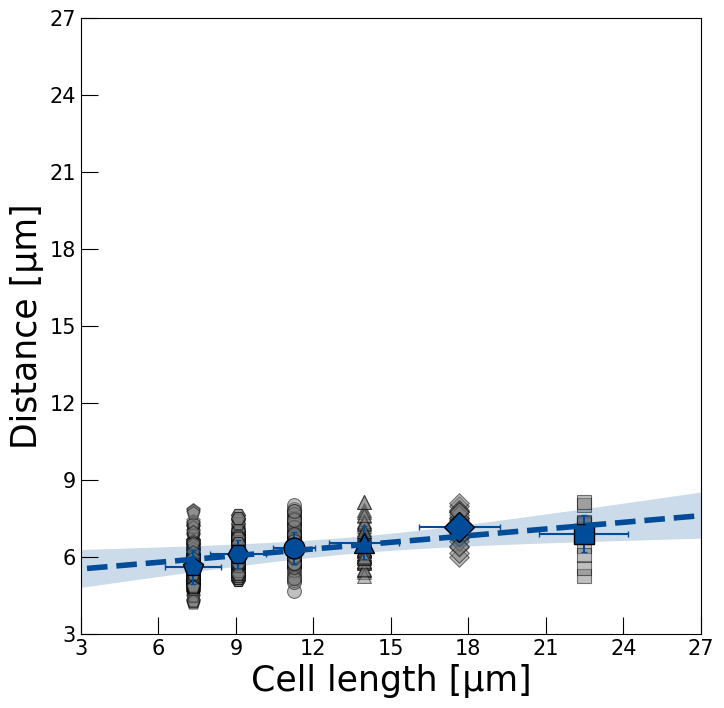

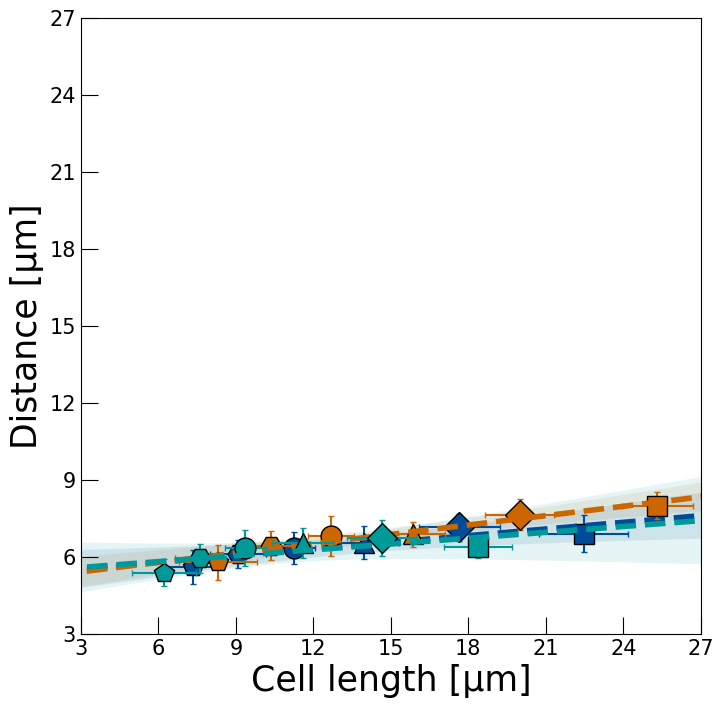

In [6]:
analysis_summary = SpindleAnalysis(folder, fileTable)
analysis_summary.plot_WildType_final_distances()
# analysis_summary.plot_Big_final_distances()
# analysis_summary.plot_Small_final_distances()
analysis_summary.plot_combined_summary()
# analysis_summary.parameter_summary()